# L7b Lab: Singular Value Decomposition of a Platelet Metabolic Network

Platelets are small cell fragments in our blood that help form a clot when a blood vessel is damaged. Like every living cell, a platelet runs a network of chemical reactions, its __metabolism__, which turns nutrients such as glucose into energy and building blocks. The chemical species that these reactions consume and produce are called __metabolites__.

In L6a, we wrote a reaction network as a stoichiometric matrix, with one row for each metabolite and one column for each reaction. A realistic network has hundreds of rows and columns, and not all of its metabolite balances are independent. The singular value decomposition (SVD) of the stoichiometric matrix tells us which weighted sums of metabolites the network conserves, and which combinations of reaction rates keep every metabolite in balance.

> __Learning Objectives:__
>
> By the end of this lab, you should be able to:
>
> * __Build the stoichiometric matrix of a metabolic model:__ A BiGG model file lists every reaction with its metabolites and their stoichiometric coefficients. We'll load a human platelet model, read its metabolite and reaction records, and assemble its stoichiometric matrix.
> * __Compute the rank and low-rank approximations of the matrix:__ The rank of the stoichiometric matrix is the number of independent metabolite balances, and the singular values measure how much each piece of the SVD contributes to the matrix. We'll compute the full SVD, find the numerical rank, and build approximations of the matrix from its largest singular values.
> * __Interpret the two nullspaces of the matrix:__ The left nullspace holds the weighted metabolite pools that the reactions conserve, and the right nullspace holds the combinations of reaction rates that keep every metabolite balanced. We'll extract both from the SVD and check whether a balanced flux also satisfies the reaction bounds.

In [the L7a lecture](../L7a/CHEME-5800-L7a-Lecture-SVDAndDataReduction-Fall-2026.ipynb), we introduced the singular value decomposition, which factors any rectangular matrix into two orthonormal bases and a set of ranked singular values. Here, we apply the SVD to the stoichiometric matrix of `iAT_PLT_636`, a human platelet model from [BiGG Models](http://bigg.ucsd.edu/) ([Thomas et al., 2014](https://pubmed.ncbi.nlm.nih.gov/24473230/)), to explore the structure of a metabolic network.

Let's get started!

___

## Setup, Data, and Prerequisites

First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project, defines local paths, and loads the packages and the BiGG download helpers used here.

Let's set up our code environment:

In [1]:
# Load packages and paths from this notebook's local setup file -
include(joinpath(@__DIR__, "Include.jl"));

# Choose one theme; after changing it, rerun this cell and the plotting cells -
theme(:default)   # light background
# theme(:dark)   # dark background

See the [Julia documentation](https://docs.julialang.org/en/v1/) and the [course package documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for the functions and types used here.

The platelet model is saved in [data/saved-model-iAT_PLT_636.jld2](data/saved-model-iAT_PLT_636.jld2), and [data/README.md](data/README.md) describes its source. The BiGG download helpers live in [src/BiGG.jl](src/BiGG.jl); we need them only if the saved file is missing.

___

## Task 1: Build the stoichiometric matrix

In this task, we load the platelet model, look at how it stores metabolites and reactions, and assemble its stoichiometric matrix $\mathbf{S}$.

The code below loads the saved model. If the saved file is missing, it downloads the model from BiGG and saves a copy for next time:

In [2]:
model = let

    # Select the model and cache file -
    baseurl = "http://bigg.ucsd.edu"; # base url to download model
    modelid = "iAT_PLT_636"; # BiGG identifier; changing it selects a different cache file
    path_to_saved_model_file = joinpath(CHEME5800_L7B_DATA, "saved-model-$(modelid).jld2"); # $(...) inserts the model id into the file name

    # Download only when the local cache is absent -
    model = nothing;
    if (isfile(path_to_saved_model_file) == false)
        
        endpoint = MyBiggModelsDownloadModelEndpointModel(); # describes the BiGG download request
        endpoint.bigg_id = modelid;
        url = build(baseurl, endpoint); # the download URL for this model
        model = MyBiggModelsDownloadModelEndpointModel(url); # Hmmmm. Tricky, why can we call a type like a function? (see src/Network.jl)

        # Cache the model for subsequent runs -
        save(path_to_saved_model_file, Dict("model" => model));
    else
        model = load(path_to_saved_model_file)["model"];
    end
    model; # return the model (either saved, or downloaded)
end;

__What's in the model?__ The model holds a list of metabolite records and a list of reaction records. Each metabolite record has an identifier, a name, and a compartment, the part of the cell where the metabolite is found. For example, `c` is the cytosol (the fluid inside the cell), `m` is the mitochondria, and `e` is the space outside the cell.

Let's look at the record for glucose in the cytosol:

In [3]:
let
    i = findfirst(x -> x["id"] == "glc__D_c", model["metabolites"]); # row index of glucose in the cytosol
    metabolite = model["metabolites"][i]; # the glucose record
    (id = metabolite["id"], name = metabolite["name"], compartment = metabolite["compartment"])
end

(id = "glc__D_c", name = "D-Glucose", compartment = "c")

Each reaction record has an identifier, a name, and a `metabolites` field that maps metabolite identifiers to stoichiometric coefficients. Let's look at hexokinase (`HEX1`), the first step in breaking down glucose, which uses one ATP to attach a phosphate group to glucose:

In [4]:
let
    j = findfirst(x -> x["id"] == "HEX1", model["reactions"]); # column index of hexokinase
    reaction = model["reactions"][j]; # the hexokinase record
    reaction["metabolites"] # metabolite identifiers and stoichiometric coefficients
end

JSON.Object{String, Any} with 5 entries:
  "adp_c"    => 1.0
  "atp_c"    => -1.0
  "g6p_c"    => 1.0
  "glc__D_c" => -1.0
  "h_c"      => 1.0

__What do we see?__ Hexokinase consumes glucose (`glc__D_c`) and ATP (`atp_c`), so their coefficients are $-1$. It produces glucose 6-phosphate (`g6p_c`), ADP (`adp_c`), and a proton (`h_c`), so their coefficients are $+1$. Every metabolite that does not take part in hexokinase has a zero coefficient.

__Build the matrix.__ We put metabolites on the rows and reactions on the columns. For $m$ metabolites and $n$ reactions, the stoichiometric matrix $\mathbf{S}\in\mathbb{R}^{m\times n}$ holds the coefficient of metabolite $i$ in reaction $j$ in row $i$ and column $j$.

The code loops over the metabolites (rows), and for each metabolite, over the reactions (columns). When the metabolite takes part in the reaction, we copy its coefficient into $\mathbf{S}$; otherwise, the entry stays zero:

In [5]:
S = let

    # Read the records and allocate the matrix -
    metabolites = model["metabolites"]; # row order
    reactions = model["reactions"]; # column order
    number_of_metabolites = length(metabolites); # m, the number of rows
    number_of_reactions = length(reactions); # n, the number of columns
    S = zeros(number_of_metabolites, number_of_reactions); # every entry starts at zero

    # Match each metabolite identifier to its reaction coefficients -
    for i ∈ eachindex(metabolites)
        metabolite_id = metabolites[i]["id"]; # e.g., "glc__D_c"
        for j ∈ eachindex(reactions)
            coefficients = reactions[j]["metabolites"]; # identifier => coefficient for reaction j
            if haskey(coefficients, metabolite_id) # does metabolite i take part in reaction j?
                S[i, j] = coefficients[metabolite_id];
            end
        end
    end
    S; # return the stoichiometric matrix
end;

Let's check the size of the matrix with [the `size(...)` function](https://docs.julialang.org/en/v1/base/arrays/#Base.size) and count its nonzero entries:

In [6]:
(size = size(S), nonzero_entries = count(!iszero, S)) # (metabolites, reactions), and the entries that are not zero

(size = (738, 1008), nonzero_entries = 4006)

__What do we see?__ The matrix has 738 rows (metabolites) and 1008 columns (reactions), but only 4006 of its 743,904 entries are nonzero. There are more reactions than metabolites, so the balances alone cannot determine every reaction rate.

To see where the nonzero entries sit, we draw $\mathbf{S}$ as a grayscale image with one pixel per entry. Coefficients below $-0.05$ are black, coefficients above $0.05$ are white, and everything in between is gray. We'll use the same colors for the approximations in Task 2:

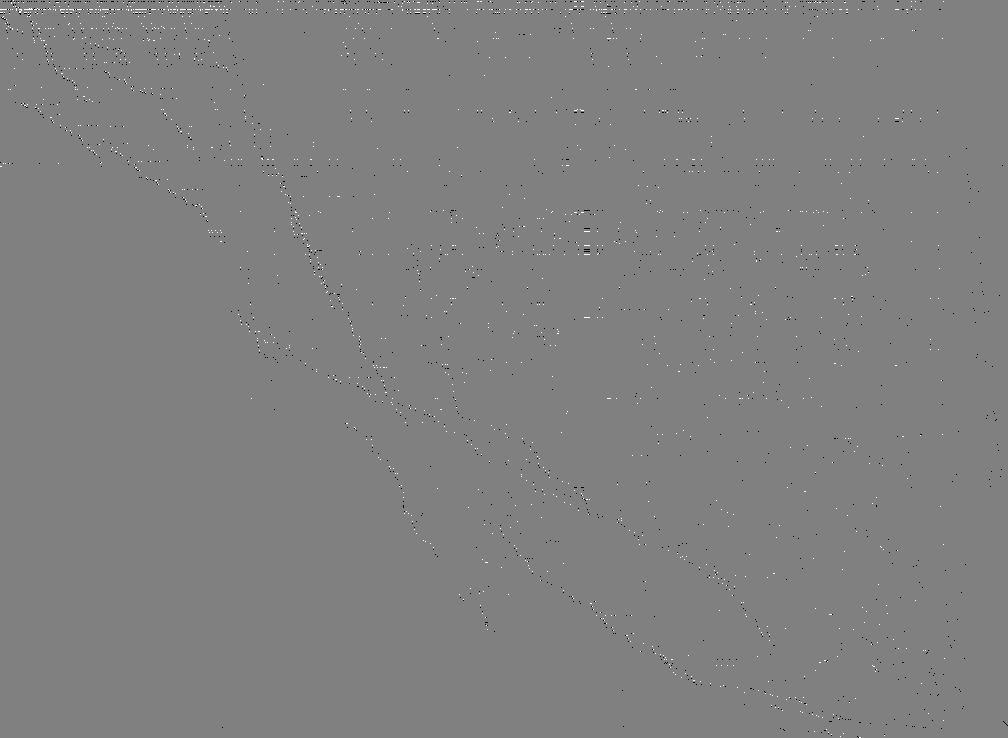

In [7]:
# Draw S: black for negative, white for positive, gray for zero -
display_threshold = 0.05; # entries within ±0.05 of zero are drawn gray
original_image = Gray.(ifelse.(S .< -display_threshold, 0.0,
    ifelse.(S .> display_threshold, 1.0, 0.5))) # fancy, what is going on here?

__What do we see?__ Most of the image is gray. The nonzero entries form a few diagonal bands, and a few rows near the top are much denser than the rest; they belong to metabolites such as water and protons, which take part in hundreds of reactions.

### Things to think about

__Question:__ Why does each column of $\mathbf{S}$ have only a few nonzero entries? Some columns have exactly one nonzero entry. What does a reaction with a single metabolite do? Where have we seen reactions like this before?

___

## Task 2: Compute the rank and low-rank approximations

In this task, we compute the full SVD of $\mathbf{S}$, find its rank, and build approximations of $\mathbf{S}$ from its largest singular values.

In L7a, we wrote the full SVD of a matrix $\mathbf{A}$ as $\mathbf{A}=\mathbf{U}\mathbf{S}\mathbf{V}^{\top}$. Here, $\mathbf{S}$ is the stoichiometric matrix, so we write $\boldsymbol{\Sigma}$ for the matrix of singular values. The full SVD of the stoichiometric matrix is given by:

$$
\mathbf{S}=\mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^{\top},
$$
where $\mathbf{U}\in\mathbb{R}^{m\times m}$ has orthonormal columns $\mathbf{u}_{i}$ ($\mathbf{U}^{\top}\mathbf{U}=\mathbf{I}_{m}$, the $m\times m$ identity matrix), $\mathbf{V}\in\mathbb{R}^{n\times n}$ has orthonormal columns $\mathbf{v}_{i}$ ($\mathbf{V}^{\top}\mathbf{V}=\mathbf{I}_{n}$, the $n\times n$ identity matrix), and $\boldsymbol{\Sigma}\in\mathbb{R}^{m\times n}$ holds the singular values $\sigma_{1}\geq\sigma_{2}\geq\cdots\geq0$ on its diagonal. The columns of $\mathbf{U}$ live in metabolite space, and the columns of $\mathbf{V}$ live in reaction space.

We use [the `svd(...)` function](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.svd) with `full=true`, which keeps all $m$ columns of $\mathbf{U}$ and all $n$ columns of $\mathbf{V}$; we need the complete bases for the nullspaces in Task 3. Julia returns the singular values as a vector `Σ`:

In [8]:
# Compute the full SVD of S -
# QRIteration() is slower than the default algorithm, but more accurate
U, Σ, V = svd(S; alg = LinearAlgebra.QRIteration(), full = true);
(size_U = size(U), size_V = size(V), number_of_singular_values = length(Σ))

(size_U = (738, 738), size_V = (1008, 1008), number_of_singular_values = 738)

### Numerical rank

In exact arithmetic, the rank of $\mathbf{S}$ is the number of nonzero singular values. On a computer, rounding error turns a singular value that should be zero into a tiny positive number, so we count only the singular values above a tolerance:

$$
\tau=\epsilon\,\max(m,n)\,\sigma_{1},
\qquad
r=\#\left\{i:\sigma_{i}>\tau\right\},
$$
where $\epsilon\approx2.22\times10^{-16}$ is the spacing between $1.0$ and the next larger `Float64` number, $\sigma_{1}$ is the largest singular value, and $\#$ counts the singular values above $\tau$. Scaling by $\max(m,n)\,\sigma_{1}$ matches the tolerance to the size of the matrix and its entries. The count $r$ is the __numerical rank__ of $\mathbf{S}$.

__Prediction:__ The stoichiometric matrix has 738 rows and 1008 columns, so its rank is at most 738. Is the rank of $\mathbf{S}$ {equal to 738, or less than 738}?

In [9]:
# Count the singular values above the tolerance -
m, n = size(S); # number of metabolites (rows) and reactions (columns)
τ = eps(Float64) * max(m, n) * Σ[1]; # tolerance scaled to the matrix size and its largest singular value
r = count(σ -> σ > τ, Σ); # numerical rank: the number of singular values above τ
σ_next = r < length(Σ) ? Σ[r + 1] : 0.0; # first singular value below τ; a ? b : c reads "if a, then b, else c"
(tolerance = τ, rank = r, σ_r = Σ[r], σ_next = σ_next)

(tolerance = 9.450865353691485e-12, rank = 719, σ_r = 0.03230178003799801, σ_next = 2.8803392246749877e-15)

__What do we see?__ The rank is 719, less than 738. The 719th singular value is about $0.03$, while the next one is about $3\times10^{-15}$, far below the tolerance $\tau\approx9.5\times10^{-12}$. This gap of more than ten orders of magnitude makes the rank clear. That leaves $m-r=19$ directions in metabolite space and $n-r=289$ directions in reaction space, which are the two nullspaces we explore in Task 3.

### How much does each mode contribute?

Each __mode__ of the SVD is a triplet $(\sigma_{i},\mathbf{u}_{i},\mathbf{v}_{i})$ with $\mathbf{S}\mathbf{v}_{i}=\sigma_{i}\mathbf{u}_{i}$. In words, running the reactions in the combination $\mathbf{v}_{i}$ changes the metabolites in the pattern $\sigma_{i}\mathbf{u}_{i}$. Keeping the first $k$ modes gives the rank-$k$ approximation of $\mathbf{S}$:

$$
\mathbf{S}_{k}=\sum_{i=1}^{k}\sigma_{i}\,\mathbf{u}_{i}\mathbf{v}_{i}^{\top}.
$$

To measure how much of $\mathbf{S}$ the first $k$ modes capture, we use the squared Frobenius norm, the sum of the squared entries of a matrix. The fraction captured, and the relative error of the approximation, are given by:

$$
F_{k}=\frac{\sum_{i=1}^{k}\sigma_{i}^{2}}{\sum_{i=1}^{\min(m,n)}\sigma_{i}^{2}},
\qquad
\frac{\|\mathbf{S}-\mathbf{S}_{k}\|_{F}}{\|\mathbf{S}\|_{F}}=\sqrt{1-F_{k}},
$$
where $\|\cdot\|_{F}$ denotes the Frobenius norm. Let's plot $F_{k}$ against the number of modes $k$:

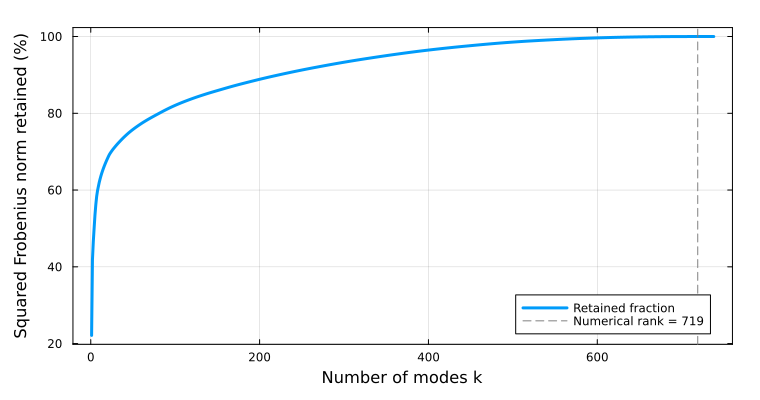

In [10]:
# Fraction of the squared Frobenius norm captured by the first k modes -
retained_fraction = cumsum(abs2.(Σ)) / sum(abs2, Σ); # F_k for k = 1, 2, ..., m

# Plot F_k and mark the numerical rank -
let
    p = plot(eachindex(Σ), 100 .* retained_fraction;
        xlabel = "Number of modes k", ylabel = "Squared Frobenius norm retained (%)",
        label = "Retained fraction", linewidth = 3, legend = :bottomright,
        framestyle = :box, size = (760, 400), margin = 5Plots.mm);
    vline!(p, [r]; label = "Numerical rank = $(r)", linestyle = :dash, color = :gray); # the ! adds the line to the existing plot
    p;
end

__What do we see?__ The first four modes capture half of the squared norm, but then the curve rises slowly: we need about 220 modes to capture 90% and about 530 modes to capture 99%. The curve reaches 100% at the numerical rank, since the singular values after it are zero to numerical precision.

__Build the rank-$k$ approximation yourself__: The sum of $k$ outer products in $\mathbf{S}_{k}$ can be written as a product of three matrices built from the first $k$ modes. Build `S_k::Array{Float64,2}` this way, using `U`, `Σ`, and `V`. [The `Diagonal(...)` function](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.Diagonal) builds a diagonal matrix from a vector.

The test at the end passes when the relative error of your approximation matches $\sqrt{1-F_{k}}$. The cell then draws your approximation with the same colors as $\mathbf{S}$:

In [ ]:
# Choose how many modes to keep -
k = 400; # number of modes, from 1 to r

# TODO 1: build the rank-k approximation from the first k columns of U, the first k singular
# values, and the first k columns of V. Diagonal(Σ[1:k]) builds the k×k diagonal matrix.
S_k = nothing;

# check: the error of your approximation matches the singular values -
isnothing(S_k) && throw(ErrorException("Complete TODO 1 above, then run this cell again")); # && runs the throw only when S_k is still nothing
relative_error = norm(S - S_k) / norm(S); # for a matrix, norm(...) is the Frobenius norm
@testset "My rank-k approximation" begin
    @test size(S_k) == size(S)
    @test relative_error^2 ≈ 1 - retained_fraction[k] atol = 1e-10 # squared relative error = share of σ² left out
end;
println("modes = $(k), retained = $(round(100 * retained_fraction[k]; digits = 2))%, relative error = $(round(relative_error; digits = 4))");

# Draw the approximation with the same colors as S -
approximation_image = Gray.(ifelse.(S_k .< -display_threshold, 0.0,
    ifelse.(S_k .> display_threshold, 1.0, 0.5)))

__What do we see?__ With 400 of the 719 modes, the approximation captures about 96.5% of the squared norm, and its relative error is about 18.8%. The diagonal bands of $\mathbf{S}$ are still visible, but speckles now appear where $\mathbf{S}$ has zeros: the approximation spreads small nonzero values across the matrix.

### Your turn

Change `k` in the cell above, predict what happens to the image and the relative error, then run the cell again. Try a few modes (`k = 10`), about half of the rank (`k = 360`), and every mode above the tolerance (`k = r`).

### Things to think about

__Question:__ How many modes does it take before the image looks like $\mathbf{S}$? Why is the relative error zero, to numerical precision, when $k = r$? Would keeping more than $r$ modes change the approximation?

___

## Task 3: Find conserved pools and balanced fluxes

In this task, we extract the left and right nullspaces of $\mathbf{S}$ from the full SVD, interpret what they mean for the metabolic network, and check whether a balanced flux satisfies the reaction bounds.

### Conserved metabolite pools (left nullspace)

The __left nullspace__ of $\mathbf{S}$ is the set of weight vectors $\mathbf{w}\in\mathbb{R}^{m}$ with $\mathbf{S}^{\top}\mathbf{w}=\mathbf{0}$. It has dimension $m-r$, and the last $m-r$ columns of the full matrix $\mathbf{U}$ are an orthonormal basis for it. We collect these columns in $\mathbf{U}_{0}\in\mathbb{R}^{m\times(m-r)}$.

Why does this give a conservation law? Let $\mathbf{x}(t)$ hold the amounts of the $m$ metabolites, which change as $d\mathbf{x}/dt=\mathbf{S}\mathbf{v}(t)$, where $\mathbf{v}(t)$ is the vector of reaction rates (fluxes). For any $\mathbf{w}$ in the left nullspace, the weighted sum $\mathbf{w}^{\top}\mathbf{x}$ does not change:

$$
\frac{d}{dt}\left(\mathbf{w}^{\top}\mathbf{x}\right)=\mathbf{w}^{\top}\mathbf{S}\mathbf{v}=\left(\mathbf{S}^{\top}\mathbf{w}\right)^{\top}\mathbf{v}=0.
$$

Thus, each vector in the left nullspace defines a weighted pool of metabolites whose total stays constant, no matter how fast the reactions run.

Let's extract $\mathbf{U}_{0}$ and check that $\mathbf{S}^{\top}\mathbf{U}_{0}$ is zero to numerical precision:

In [12]:
# Extract the left-nullspace basis and check it -
U0 = U[:, (r+1):m]; # the last m - r columns of U
left_residual = maximum(abs, transpose(S) * U0); # largest entry of S'U0, which should be zero
@testset "Left nullspace" begin
    @test size(U0) == (m, m - r) # one column per conservation relation
    @test left_residual < τ # zero, to within the rank tolerance
end;
(conservation_relations = size(U0, 2), largest_residual = left_residual)

Test Summary:  | Pass  Total  Time
Left nullspace |    2      2  0.0s


(conservation_relations = 19, largest_residual = 2.0747292772682613e-15)

__What do we see?__ The platelet model has 19 independent conservation relations, and the largest entry of $\mathbf{S}^{\top}\mathbf{U}_{0}$ is about $2\times10^{-15}$. To see which metabolites a relation involves, we list the 15 largest weights (in magnitude) in one column of $\mathbf{U}_{0}$:

In [13]:
let
    relation_index = 3; # which column of U0 to inspect, from 1 to 19
    weights = U0[:, relation_index]; # the weights of one conservation relation
    rows = sortperm(abs.(weights); rev = true)[1:15]; # rows of the 15 largest weights in magnitude

    # put data into a DataFrame for pretty printing -
    df = DataFrame(
        metabolite = [model["metabolites"][i]["id"] for i ∈ rows],
        name = [model["metabolites"][i]["name"] for i ∈ rows],
        weight = round.(weights[rows]; digits = 4),
    );

    # let's write a pretty table of the largest weights -
    pretty_table(df; backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
        column_labels = ["Metabolite", "Name", "Weight"],
        alignment = [:l, :l, :r]);
end

 ------------ ------------------------------------------------------- ---------
  Metabolite   Name                                                     Weight 
 ------------ ------------------------------------------------------- ---------
  nadh_c       Nicotinamide adenine dinucleotide - reduced               0.242
  nad_c        Nicotinamide adenine dinucleotide                         0.242
  nmn_c        NMN C11H14N2O8P                                           0.242
  rnam_c       N Ribosylnicotinamide C11H15N2O5                          0.242
  ncam_c       Nicotinamide                                              0.242
  nadp_m       Nicotinamide adenine dinucleotide phosphate             -0.2001
  nadph_m      Nicotinamide adenine dinucleotide phosphate - reduced   -0.2001
  nad_m        Nicotinamide adenine dinucleotide                        0.1604
  nadh_m       Nicotinamide adenine dinucleotide - reduced              0.1604
  estrones_c   Estrone 3-sulfate                 

__What do we see?__ The weights come in groups of equal value, and each group is a family of related metabolites: NAD⁺ and NADH in the cytosol with three molecules the cell builds them from (`nmn_c`, `rnam_c`, `ncam_c`), NADP⁺ and NADPH in the mitochondria, NAD⁺ and NADH in the mitochondria, estrone and estrone sulfate, and NADP⁺ and NADPH in the cytosol and the endoplasmic reticulum (`r`). NAD⁺, NADH, NADP⁺, and NADPH carry electrons between reactions.

Each family by itself is a conserved pool: every reaction that consumes one member of the family produces another member in return. A single column of $\mathbf{U}_{0}$ mixes several pools, because any combination of vectors in the left nullspace is also in the left nullspace.

### Balanced fluxes (right nullspace)

The __right nullspace__ of $\mathbf{S}$ is the set of flux vectors $\mathbf{v}\in\mathbb{R}^{n}$ with $\mathbf{S}\mathbf{v}=\mathbf{0}$. These are the steady-state fluxes from L6a: every metabolite is produced as fast as it is consumed. The right nullspace has dimension $n-r$, and the last $n-r$ columns of the full matrix $\mathbf{V}$ are an orthonormal basis for it. Every balanced flux vector is a combination of these columns:

$$
\mathbf{v}=\mathbf{V}_{0}\mathbf{a},
$$
where $\mathbf{V}_{0}\in\mathbb{R}^{n\times(n-r)}$ holds the last $n-r$ columns of $\mathbf{V}$, and $\mathbf{a}\in\mathbb{R}^{n-r}$ holds the combination weights.

Let's extract $\mathbf{V}_{0}$ and check that $\mathbf{S}\mathbf{V}_{0}$ is zero to numerical precision:

In [14]:
# Extract the right-nullspace basis and check it -
V0 = V[:, (r+1):n]; # the last n - r columns of V; only the full SVD has them
right_residual = maximum(abs, S * V0); # largest entry of S*V0, which should be zero
@testset "Right nullspace" begin
    @test size(V0) == (n, n - r) # one column per balanced-flux direction
    @test right_residual < τ # zero, to within the rank tolerance
end;
(balanced_flux_directions = size(V0, 2), largest_residual = right_residual)

Test Summary:   | Pass  Total  Time
Right nullspace |    2      2  0.0s


(balanced_flux_directions = 289, largest_residual = 3.0531133177191805e-15)

__What do we see?__ The model has 289 independent balanced-flux directions, and the largest entry of $\mathbf{S}\mathbf{V}_{0}$ is about $3\times10^{-15}$. Every flux vector that balances all 738 metabolites is a combination of these 289 columns.

### Does a balanced flux satisfy the bounds?

A feasible flux in the L6a flux balance problem must be balanced, and it must also stay within the bounds of every reaction, $\mathbf{v}^{L}\leq\mathbf{v}\leq\mathbf{v}^{U}$, where $\mathbf{v}^{L}$ and $\mathbf{v}^{U}$ hold the lower and upper bounds. In this model, 559 of the 1008 reactions have a lower bound of zero, so they can only run forward.

__Prediction:__ Let's take column 10 of $\mathbf{V}_{0}$ as a trial flux vector. It balances every metabolite. Does it also satisfy every reaction bound {yes, or no}?

Let's list its 12 largest entries (in magnitude) with the bounds of each reaction. A positive entry runs a reaction forward, and a negative entry runs it backward:

In [15]:
flux_direction_index = 10; # which column of V0 to use, from 1 to 289
let
    direction = V0[:, flux_direction_index]; # one balanced flux vector
    rows = sortperm(abs.(direction); rev = true)[1:12]; # rows of the 12 largest entries in magnitude

    # put data into a DataFrame for pretty printing -
    df = DataFrame(
        reaction = [model["reactions"][j]["id"] for j ∈ rows],
        flux = round.(direction[rows]; digits = 4),
        lower = [model["reactions"][j]["lower_bound"] for j ∈ rows],
        upper = [model["reactions"][j]["upper_bound"] for j ∈ rows],
    );

    # let's write a pretty table of the largest entries and their bounds -
    pretty_table(df; backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
        column_labels = ["Reaction", "Flux", "Lower bound", "Upper bound"],
        alignment = [:l, :r, :r, :r]);
end

 -------------------- --------- ------------- -------------
  Reaction                Flux   Lower bound   Upper bound 
 -------------------- --------- ------------- -------------
  VALtec               -0.1587       -1000.0        1000.0
  PI345P3P_18_1_18_1   -0.1492           0.0        1000.0
  URIt5                 0.1427       -1000.0        1000.0
  PI4P5K_18_1_18_1     -0.1301           0.0        1000.0
  O2Stm                  -0.13       -1000.0        1000.0
  DAGK_hs_18_2_18_2     0.1166       -1000.0        1000.0
  FATP2t                0.1148       -1000.0        1000.0
  PPA                   0.1127           0.0        1000.0
  CEPTC_18_1_18_2       0.1075           0.0        1000.0
  PIPLC_18_2_18_2      -0.1059           0.0        1000.0
  PI345P3P_16_0_16_0    0.1022           0.0        1000.0
  VALt4                 0.0959       -1000.0        1000.0
 -------------------- --------- ------------- -------------


The table shows only 12 of the 1008 reactions. Let's check the trial flux against every reaction bound:

In [16]:
# Check the trial flux against every reaction bound -
v_trial = V0[:, flux_direction_index]; # one balanced flux vector (column 10 of V0)
lower_bounds = [reaction["lower_bound"] for reaction ∈ model["reactions"]]; # v^L
upper_bounds = [reaction["upper_bound"] for reaction ∈ model["reactions"]]; # v^U
bound_tolerance = 1e-8; # allowed slack for roundoff, in the model's flux units
below_lower = findall(v_trial .< lower_bounds .- bound_tolerance); # reactions below their lower bound
above_upper = findall(v_trial .> upper_bounds .+ bound_tolerance); # reactions above their upper bound
violations = union(below_lower, above_upper); # every reaction outside its bounds
(balance_residual = maximum(abs, S * v_trial), below_lower = length(below_lower),
 above_upper = length(above_upper), violated_bounds = length(violations))

(balance_residual = 1.5855372570428017e-15, below_lower = 270, above_upper = 1, violated_bounds = 271)

__What do we see?__ The trial flux balances every metabolite to about $10^{-15}$, but it breaks 271 of the 1008 reaction bounds, 270 of them by running an irreversible reaction backward. It is not a feasible flux for this model. Finding a combination of the columns of $\mathbf{V}_{0}$ that satisfies every bound, while optimizing an objective, is the linear program we solved with flux balance analysis in L6a.

### Things to think about

__Question:__ Why does a column of $\mathbf{V}_{0}$ break so many bounds? Which information about the reactions does the SVD use, and which does it ignore? What does flux balance analysis add to pick one feasible flux distribution from the right nullspace?

___

## Summary

In this lab, we used the singular value decomposition to explore the structure of the stoichiometric matrix of a human platelet metabolic model.

> __Key Takeaways:__
>
> * __The platelet matrix has rank 719, not 738:__ We built the stoichiometric matrix of the platelet model and counted its singular values above a rounding tolerance. The 19 missing metabolite directions and the 289 leftover reaction directions are the two nullspaces of the matrix.
>
> * __A few modes capture much of the matrix, but not all of it:__ We built low-rank approximations from the largest singular values and measured their error. The first four modes captured half of the squared norm, but we needed every mode up to the rank to recover the matrix.
>
> * __Balanced fluxes need not be feasible:__ We found conserved metabolite pools in the left nullspace and balanced fluxes in the right nullspace. A balanced flux from the SVD broke 271 reaction bounds, so flux balance analysis adds the bounds and an objective to select a feasible flux.

In L7c, we turn to ordinary least squares, which fits a model to data by projecting the observations onto the column space of a matrix.

___